In [1]:
import pandas as pd 
import yfinance as yf 
import pyfolio as pf

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [2]:
tickers = ['VT', 'IXC', 'AMZN', 'GOOGL', 'EADSY', 'DHT']
weights = pd.Series([0.55, 0.15, 0.11, 0.09, 0.04, 0.04], index=tickers)

In [3]:
prices = None 
for t in tickers:
    h = yf.Ticker(t).history('max')[['Close']].rename(columns ={'Close':t})
    prices = h if prices is None else prices.join(h, how='inner')

In [4]:
prices

,VT,IXC,AMZN,GOOGL,EADSY,DHT
Date,,,,,,
2008-06-26 00:00:00-04:00,33.996647,26.921141,3.815000,13.125254,3.695588,32.694237
2008-06-27 00:00:00-04:00,33.941788,27.307365,3.733000,13.106638,3.637995,32.694237
2008-06-30 00:00:00-04:00,33.969238,27.801081,3.666500,13.065685,3.616877,32.792324
2008-07-01 00:00:00-04:00,33.667530,27.746429,3.681000,13.271938,3.532406,32.171116
2008-07-02 00:00:00-04:00,33.173820,26.738947,3.572000,13.081075,3.549685,31.124903
...,...,...,...,...,...,...
2026-03-18 00:00:00-04:00,139.492371,55.139999,209.869995,307.690002,48.250000,17.500000
2026-03-19 00:00:00-04:00,139.223007,55.990002,208.759995,307.130005,47.560001,17.860001
2026-03-20 00:00:00-04:00,136.320007,55.639999,205.369995,301.000000,46.259998,17.270000


In [5]:
asset_rets = prices.pct_change().dropna()
returns = asset_rets.mul(weights).sum(axis=1)
returns

Date
2008-06-27 00:00:00-04:00   -0.001851
2008-06-30 00:00:00-04:00    0.000804
2008-07-01 00:00:00-04:00   -0.005016
2008-07-02 00:00:00-04:00   -0.019169
2008-07-03 00:00:00-04:00    0.004772
                               ...   
2026-03-18 00:00:00-04:00   -0.011216
2026-03-19 00:00:00-04:00    0.000755
2026-03-20 00:00:00-04:00   -0.018403
2026-03-23 00:00:00-04:00    0.015832
2026-03-24 00:00:00-04:00   -0.001263
Length: 4462, dtype: float64

In [6]:
bench = yf.Ticker('SPY').history('max')
bench_returns = bench.Close.pct_change()

In [7]:
returns, bench_returns = returns.align(bench_returns, join = 'inner')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.73%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '23.224%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in 

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,46.46,2008-06-30,2008-11-20,2010-01-04,396
1,34.21,2020-01-17,2020-03-23,2020-08-24,157
2,21.65,2011-07-22,2011-10-03,2013-01-04,381
3,20.47,2018-08-29,2018-12-24,2019-04-23,170
4,20.07,2022-03-29,2022-09-30,2023-06-15,318


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyfolio/plotting.py:1391: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.swarmplot(
/Library/Frameworks/Python.framework/Versions/3.13/l

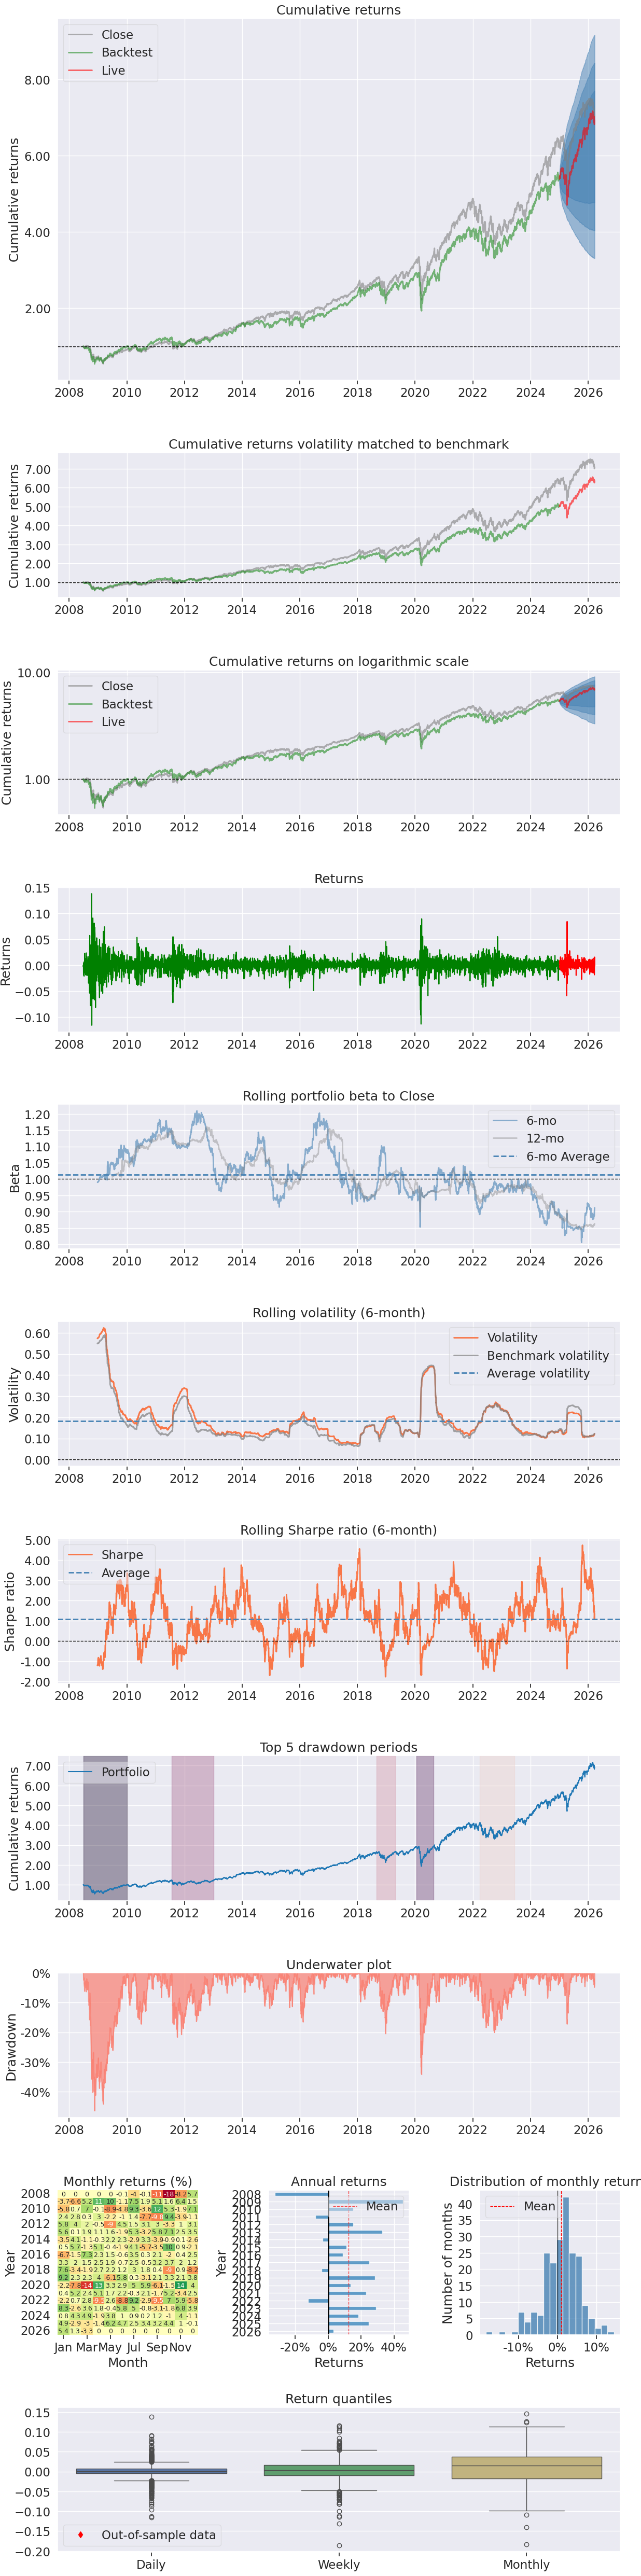

In [8]:
pf.create_returns_tear_sheet(returns, live_start_date='2025-01-01', benchmark_rets=bench_returns)